<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marcoteran/ml/blob/master/notebooks/ml_linear_models_regression_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab" title="Abrir y ejecutar en Google Colaboratory"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marcoteran/ml/blob/master/notebooks/ml_linear_models_regression_classification.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Abrir en Kaggle" title="Abrir y ejecutar en Kaggle"/></a>
  </td>
</table>

# Sesión 03: Modelos lineales para regresión y clasificación
## Score, pérdida, regularización y thresholding como lenguaje base del modelado

**Aprendizaje de Máquina Aplicado**

**Profesor:** Marco Teran  
**Fecha:** 2026

[Website](http://marcoteran.github.io/),
[Github](https://github.com/marcoteran),
[LinkedIn](https://www.linkedin.com/in/marcoteran/).
___

## Tabla de Contenidos

1. **Introducción y objetivos**
2. **Setup reproducible**
3. **Datasets y estrategia del notebook**
4. **Rama de regresión: baseline, modelo lineal y residuos**
5. **Coeficientes e interpretación disciplinada**
6. **Scaling vs non-scaling**
7. **Regularización: Ridge y Lasso**
8. **Rama de clasificación: baseline y regresión logística**
9. **Probabilidades, threshold tuning y métricas**
10. **Glosario, ejercicios y cierre**

> **Cómo usar este notebook**  
> Recorre primero la narrativa conceptual, ejecuta después cada celda en orden y documenta tus decisiones antes de pasar al siguiente bloque. La meta no es solo que el código corra, sino entender qué parte corresponde al modelo, qué parte corresponde a la pérdida y qué parte corresponde a la política de decisión.

---
## Introducción y objetivos

En esta sesión el curso entra formalmente al modelado supervisado.

La idea no es presentar “dos algoritmos clásicos” como piezas aisladas, sino instalar la **familia lineal** como la primera baseline family seria del curso. Esta familia nos obliga a pensar con precisión en:

- score,
- pérdida,
- coeficientes,
- regularización,
- probabilidad,
- decisión.

### Objetivos de aprendizaje

Al finalizar este notebook, deberías ser capaz de:

1. Ajustar un modelo de regresión lineal y uno de regresión logística.
2. Distinguir entre score lineal, probabilidad estimada y decisión final.
3. Interpretar coeficientes de forma predictiva y condicional.
4. Explicar por qué el scaling afecta la comparabilidad de coeficientes.
5. Comparar soluciones regularizadas con Ridge y Lasso.
6. Ajustar un threshold con validación sin contaminar el test.
7. Resumir métricas y resultados de manera metodológicamente disciplinada.

### Regla central de la sesión

> Primero definimos el problema.  
> Después ajustamos el modelo.  
> Luego interpretamos la salida.  
> Y solo entonces decidimos cómo actuar.

In [1]:
print("¡Bienvenidos al notebook de la Sesión 03!")

¡Bienvenidos al notebook de la Sesión 03!


---

## Setup reproducible: Configuración del entorno

### ¿Por qué importa esta parte?

En machine learning, la reproducibilidad no es un lujo.  
Si dos personas ejecutan el mismo notebook y obtienen resultados distintos por una mala gestión del entorno, la discusión técnica se rompe.

### Qué cuidaremos aquí

- versiones mínimas razonables,
- semilla fija,
- imports explícitos,
- configuración visual simple y estable.

### Nota metodológica

Este notebook evita dependencias frágiles y datasets descargados desde fuentes inestables.  
Usaremos:

- un dataset sintético y controlado para la **rama de regresión**,
- un dataset clásico de `scikit-learn` para la **rama de clasificación**.

In [2]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings("ignore")

# Verificar versión de Python
assert sys.version_info >= (3, 9), "Este notebook requiere Python 3.9 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")

Python 3.13.5 instalado correctamente


It also requires Scikit-Learn ≥ 1.0.1:

In [3]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Optional

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [4]:
# Verificar versiones de librerías críticas
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"scikit-learn {sklearn.__version__} instalado")

scikit-learn 1.6.1 instalado


In [5]:
# Configuración visual mínima y estable
SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("✅ Entorno configurado y semilla fijada")

✅ Entorno configurado y semilla fijada


### Helpers

Los helpers de este notebook están diseñados para:

- separar train, validation y test de forma consistente,
- medir regresión y clasificación sin repetir lógica,
- inspeccionar coeficientes,
- barrer thresholds sin tocar el test para decidir políticas,
- mantener el flujo legible y reproducible.

In [6]:
from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def print_section(title: str, width: int = 88) -> None:
    """Print a visual section delimiter."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def split_train_val_test(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.20,
    val_size_within_train: float = 0.25,
    stratify: Optional[pd.Series] = None,
    random_state: int = SEED,
) -> dict:
    """Return a reproducible train/validation/test split."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify,
    )

    stratify_train = y_train_full if stratify is not None else None

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size_within_train,
        random_state=random_state,
        stratify=stratify_train,
    )

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }


try:
    from sklearn.metrics import root_mean_squared_error

    def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict:
        """Compact regression metrics."""
        return {
            "rmse": root_mean_squared_error(y_true, y_pred),
            "mae": mean_absolute_error(y_true, y_pred),
            "r2": r2_score(y_true, y_pred),
        }

except ImportError:
    def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict:
        """Compact regression metrics compatible with older sklearn."""
        mse = mean_squared_error(y_true, y_pred)
        return {
            "rmse": np.sqrt(mse),
            "mae": mean_absolute_error(y_true, y_pred),
            "r2": r2_score(y_true, y_pred),
        }


def classification_metrics(
    y_true: pd.Series,
    proba: np.ndarray,
    threshold: float,
    cost_fn: float = 5.0,
    cost_fp: float = 1.0,
) -> dict:
    """Compact classification metrics under a decision threshold."""
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    auc = roc_auc_score(y_true, proba)
    ll = log_loss(y_true, proba)
    policy_cost = cost_fn * fn + cost_fp * fp

    return {
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "roc_auc": auc,
        "log_loss": ll,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "policy_cost": policy_cost,
    }


def threshold_sweep(
    y_true: pd.Series,
    proba: np.ndarray,
    thresholds: np.ndarray,
    cost_fn: float = 5.0,
    cost_fp: float = 1.0,
) -> pd.DataFrame:
    """Evaluate many thresholds on a validation set."""
    rows = []
    for t in thresholds:
        rows.append(
            classification_metrics(
                y_true=y_true,
                proba=proba,
                threshold=float(t),
                cost_fn=cost_fn,
                cost_fp=cost_fp,
            )
        )
    return pd.DataFrame(rows)


def extract_coefficients(model, feature_names: list[str]) -> pd.DataFrame:
    """Extract coefficients from a linear model or pipeline."""
    if isinstance(model, Pipeline):
        final_estimator = model.named_steps[list(model.named_steps.keys())[-1]]
    else:
        final_estimator = model

    return pd.DataFrame(
        {
            "feature": feature_names,
            "coef": np.ravel(final_estimator.coef_),
        }
    )


def evaluate_regression_model(
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    model_name: str,
) -> dict:
    """Fit a regression model and report validation/test metrics."""
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    val_pred = fitted.predict(X_val)
    test_pred = fitted.predict(X_test)

    val_metrics = regression_metrics(y_val, val_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    return {
        "model": model_name,
        "val_rmse": val_metrics["rmse"],
        "val_mae": val_metrics["mae"],
        "val_r2": val_metrics["r2"],
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "fitted_model": fitted,
    }

---
## Datasets y estrategia del notebook

### Rama de regresión

Usaremos un dataset sintético con nombres y unidades claras:

- `area_m2`
- `habitaciones`
- `edad_edificio_anios`
- `distancia_centro_km`
- `ingreso_barrio_miles`

La razón es pedagógica:

- permite leer coeficientes con unidades comprensibles,
- permite mostrar el efecto del scaling sobre la comparabilidad,
- evita que la sesión se diluya en problemas de dominio irrelevantes para el capítulo.

### Rama de clasificación

Usaremos el dataset `breast_cancer` de `scikit-learn`, redefiniendo la clase positiva como:

- `maligno = 1`

Esto nos deja trabajar:

- score lineal,
- sigmoide,
- log loss,
- probabilidades,
- thresholding,
- política de costo asimétrico.

### Regla experimental del notebook

- Train: ajustar parámetros del modelo
- Validation: elegir hiperparámetros y threshold
- Test: evaluación final, no decisión

In [7]:
def build_regression_dataset(
    n_samples: int = 600,
    random_state: int = SEED,
) -> tuple[pd.DataFrame, pd.Series, dict]:
    """Build a controlled regression dataset with interpretable feature units."""
    rng = np.random.default_rng(random_state)

    area_m2 = rng.uniform(35, 220, n_samples)
    habitaciones = np.clip(np.round(area_m2 / 45 + rng.normal(0, 0.8, n_samples)), 1, 6)
    edad_edificio_anios = rng.uniform(0, 40, n_samples)
    distancia_centro_km = rng.uniform(0.2, 25, n_samples)
    ingreso_barrio_miles = np.clip(rng.normal(4.8, 1.1, n_samples), 1.5, 8.5)

    noise = rng.normal(0, 18, n_samples)

    precio_millones = (
        55
        + 0.95 * area_m2
        + 11.0 * habitaciones
        - 1.05 * edad_edificio_anios
        - 2.40 * distancia_centro_km
        + 8.50 * ingreso_barrio_miles
        + noise
    )

    X = pd.DataFrame(
        {
            "area_m2": area_m2,
            "habitaciones": habitaciones.astype(int),
            "edad_edificio_anios": edad_edificio_anios,
            "distancia_centro_km": distancia_centro_km,
            "ingreso_barrio_miles": ingreso_barrio_miles,
        }
    )

    y = pd.Series(precio_millones, name="precio_millones")

    units = {
        "area_m2": "m²",
        "habitaciones": "conteo",
        "edad_edificio_anios": "años",
        "distancia_centro_km": "km",
        "ingreso_barrio_miles": "miles",
    }

    return X, y, units


X_reg, y_reg, reg_units = build_regression_dataset()

print_section("DATASET DE REGRESIÓN")
print(f"Shape de X_reg: {X_reg.shape}")
print(f"Shape de y_reg: {y_reg.shape}")
display(X_reg.head())
display(y_reg.head())


                                  DATASET DE REGRESIÓN                                  
Shape de X_reg: (600, 5)
Shape de y_reg: (600,)


,area_m2,habitaciones,edad_edificio_anios,distancia_centro_km,ingreso_barrio_miles
0,178.1819,5,15.4148,6.0791,5.3284
1,116.1925,2,10.8279,20.7778,7.5851
2,193.8406,5,20.8767,13.7358,6.4281
3,164.0131,2,12.5900,19.0585,6.0313
4,52.4228,1,22.5638,11.9194,4.3734


0   280.5355
1   191.1301
2   265.1019
3   250.4973
4    88.4083
Name: precio_millones, dtype: float64

---
## Rama de regresión

En esta parte queremos responder:

1. ¿Qué tanto mejora una regresión lineal sobre una baseline ingenua?
2. ¿Cómo se ve el ajuste en términos de residuos?
3. ¿Qué significan los coeficientes?
4. ¿Qué cambia cuando escalamos?
5. ¿Qué hace la regularización a los coeficientes y al desempeño?

In [8]:
reg_split = split_train_val_test(X_reg, y_reg, stratify=None, random_state=SEED)

print_section("SPLIT DE REGRESIÓN")
print(f"Train: {reg_split['X_train'].shape[0]}")
print(f"Validation: {reg_split['X_val'].shape[0]}")
print(f"Test: {reg_split['X_test'].shape[0]}")


                                   SPLIT DE REGRESIÓN                                   
Train: 360
Validation: 120
Test: 120


### Baseline ingenua para regresión

Antes de ajustar `LinearRegression`, conviene mirar una referencia mínima:

- `DummyRegressor(strategy="mean")`

La idea no es quedarse con ella, sino tener una comparación honesta.

In [9]:
dummy_reg = DummyRegressor(strategy="mean")

dummy_reg_row = evaluate_regression_model(
    model=dummy_reg,
    X_train=reg_split["X_train"],
    y_train=reg_split["y_train"],
    X_val=reg_split["X_val"],
    y_val=reg_split["y_val"],
    X_test=reg_split["X_test"],
    y_test=reg_split["y_test"],
    model_name="DummyRegressor_mean",
)

display(pd.DataFrame([{k: v for k, v in dummy_reg_row.items() if k != "fitted_model"}]))

,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
0,DummyRegressor_mean,69.7305,57.8296,-0.0146,69.8098,61.5023,-0.0005


### LinearRegression sin scaling

Aquí aparece el primer modelo lineal serio del capítulo:

- score lineal,
- predicción continua,
- pérdida asociada al error cuadrático,
- lectura inicial de residuos.

In [10]:
linreg_raw = LinearRegression()

linreg_raw_row = evaluate_regression_model(
    model=linreg_raw,
    X_train=reg_split["X_train"],
    y_train=reg_split["y_train"],
    X_val=reg_split["X_val"],
    y_val=reg_split["y_val"],
    X_test=reg_split["X_test"],
    y_test=reg_split["y_test"],
    model_name="LinearRegression_raw",
)

linreg_raw_fitted = linreg_raw_row["fitted_model"]

regression_core_results = pd.DataFrame(
    [
        {k: v for k, v in dummy_reg_row.items() if k != "fitted_model"},
        {k: v for k, v in linreg_raw_row.items() if k != "fitted_model"},
    ]
)

print_section("BASELINE VS REGRESIÓN LINEAL")
display(regression_core_results)


                              BASELINE VS REGRESIÓN LINEAL                              


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
0,DummyRegressor_mean,69.7305,57.8296,-0.0146,69.8098,61.5023,-0.0005
1,LinearRegression_raw,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397


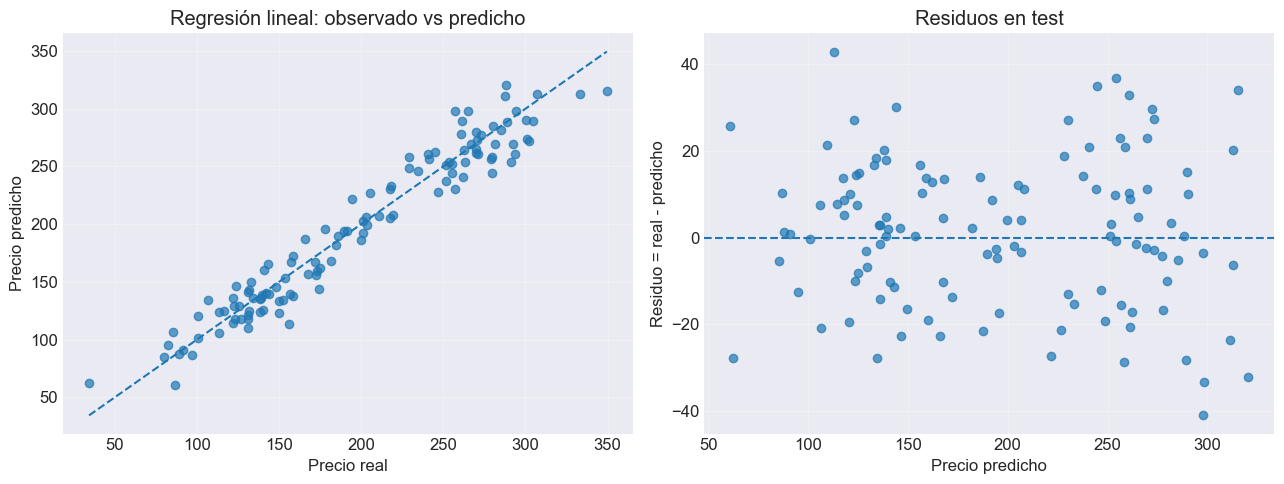

In [11]:
y_test_pred_lin_raw = linreg_raw_fitted.predict(reg_split["X_test"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(reg_split["y_test"], y_test_pred_lin_raw, alpha=0.7)
lims = [
    min(reg_split["y_test"].min(), y_test_pred_lin_raw.min()),
    max(reg_split["y_test"].max(), y_test_pred_lin_raw.max()),
]
axes[0].plot(lims, lims, linestyle="--")
axes[0].set_title("Regresión lineal: observado vs predicho")
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")

residuals_test = reg_split["y_test"] - y_test_pred_lin_raw
axes[1].scatter(y_test_pred_lin_raw, residuals_test, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuos en test")
axes[1].set_xlabel("Precio predicho")
axes[1].set_ylabel("Residuo = real - predicho")

plt.tight_layout()
plt.show()

### Lectura guiada del ajuste

Preguntas para mirar antes de seguir:

- ¿La regresión lineal mejora claramente a la baseline ingenua?
- ¿Los residuos parecen centrarse alrededor de cero?
- ¿Hay señales de error sistemático en ciertas zonas de predicción?
- ¿Qué castiga más el MSE: muchos errores pequeños o unos pocos errores grandes?

---
## Coeficientes e interpretación disciplinada

Ahora pasamos de “qué tan bien predice” a “cómo leer lo que aprendió el modelo”.

Regla de lectura:

> Manteniendo las demás variables constantes en el sentido del modelo, una unidad adicional en una feature se asocia con un cambio esperado de `β` unidades en la predicción.

Y la advertencia central:

> Un coeficiente predictivo no autoriza por sí mismo una conclusión causal.

In [12]:
coef_raw_df = extract_coefficients(linreg_raw_fitted, list(reg_split["X_train"].columns))
coef_raw_df["unidad_feature"] = coef_raw_df["feature"].map(reg_units)
coef_raw_df["abs_coef"] = coef_raw_df["coef"].abs()
coef_raw_df = coef_raw_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

print_section("COEFICIENTES SIN SCALING")
print(f"Intercepto (sin scaling): {linreg_raw_fitted.intercept_:,.4f}")
display(coef_raw_df)


                                COEFICIENTES SIN SCALING                                
Intercepto (sin scaling): 45.7046


,feature,coef,unidad_feature,abs_coef
0,habitaciones,13.3990,conteo,13.3990
1,ingreso_barrio_miles,8.8057,miles,8.8057
2,distancia_centro_km,-2.0436,km,2.0436
3,edad_edificio_anios,-1.0741,años,1.0741
4,area_m2,0.9265,m²,0.9265


### Mini chequeo conceptual

Responde verbalmente o por escrito:

- ¿Qué significa el signo de un coeficiente?
- ¿Qué significa la magnitud de un coeficiente cuando las variables tienen unidades distintas?
- ¿Por qué el intercepto no siempre merece una interpretación sustantiva?
- ¿Qué sería una mala lectura causal de este output?

---
## Scaling vs non-scaling

En OLS sin penalización, el scaling no necesariamente cambia mucho la capacidad predictiva.

Pero sí cambia algo muy importante:

- la **comparabilidad** de los coeficientes.

Eso prepara además el terreno para entender por qué la regularización necesita una escala razonablemente comparable entre variables.

In [13]:
linreg_scaled = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

linreg_scaled_row = evaluate_regression_model(
    model=linreg_scaled,
    X_train=reg_split["X_train"],
    y_train=reg_split["y_train"],
    X_val=reg_split["X_val"],
    y_val=reg_split["y_val"],
    X_test=reg_split["X_test"],
    y_test=reg_split["y_test"],
    model_name="LinearRegression_scaled",
)

linreg_scaled_fitted = linreg_scaled_row["fitted_model"]

print_section("LINEAR REGRESSION: RAW VS SCALED")
display(
    pd.DataFrame(
        [
            {k: v for k, v in linreg_raw_row.items() if k != "fitted_model"},
            {k: v for k, v in linreg_scaled_row.items() if k != "fitted_model"},
        ]
    )
)


                            LINEAR REGRESSION: RAW VS SCALED                            


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
0,LinearRegression_raw,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397
1,LinearRegression_scaled,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397


In [14]:
coef_scaled_df = extract_coefficients(linreg_scaled_fitted, list(reg_split["X_train"].columns))
coef_scaled_df["abs_coef"] = coef_scaled_df["coef"].abs()
coef_scaled_df = coef_scaled_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

coef_compare_df = (
    coef_raw_df[["feature", "coef", "unidad_feature"]]
    .rename(columns={"coef": "coef_raw"})
    .merge(
        coef_scaled_df[["feature", "coef"]].rename(columns={"coef": "coef_scaled"}),
        on="feature",
        how="left",
    )
)

print_section("COMPARACIÓN DE COEFICIENTES")
display(coef_compare_df)


                              COMPARACIÓN DE COEFICIENTES                               


,feature,coef_raw,unidad_feature,coef_scaled
0,habitaciones,13.3990,conteo,18.4061
1,ingreso_barrio_miles,8.8057,miles,9.8866
2,distancia_centro_km,-2.0436,km,-14.6961
3,edad_edificio_anios,-1.0741,años,-12.5866
4,area_m2,0.9265,m²,48.7294


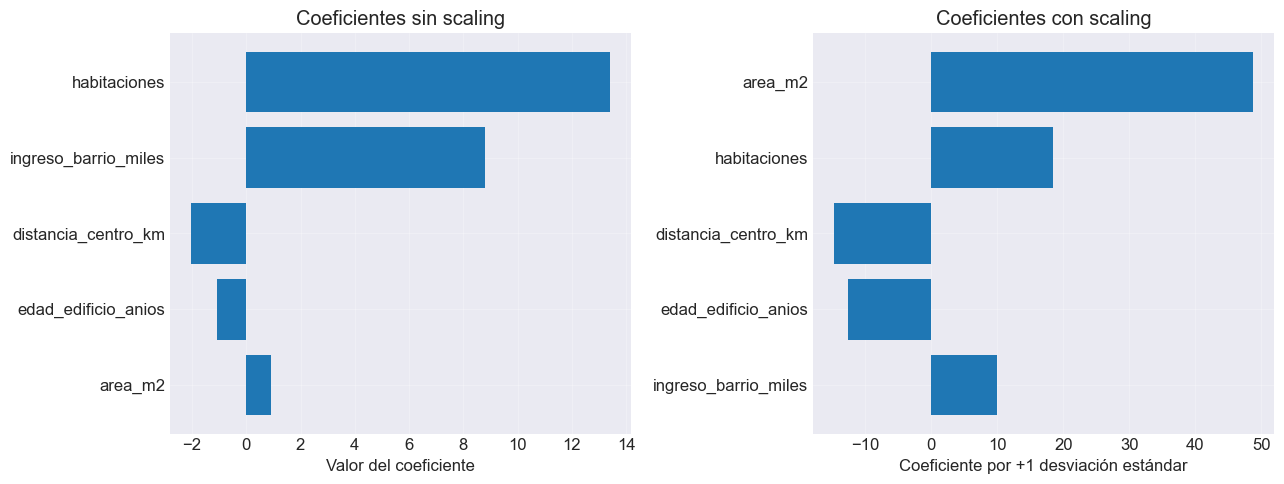

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_raw = coef_compare_df.assign(abs_raw=lambda df: df["coef_raw"].abs()).sort_values("abs_raw")
axes[0].barh(plot_raw["feature"], plot_raw["coef_raw"])
axes[0].set_title("Coeficientes sin scaling")
axes[0].set_xlabel("Valor del coeficiente")

plot_scaled = coef_compare_df.assign(abs_scaled=lambda df: df["coef_scaled"].abs()).sort_values("abs_scaled")
axes[1].barh(plot_scaled["feature"], plot_scaled["coef_scaled"])
axes[1].set_title("Coeficientes con scaling")
axes[1].set_xlabel("Coeficiente por +1 desviación estándar")

plt.tight_layout()
plt.show()

### Lectura guiada

Mientras miras las barras anteriores, pregúntate:

- ¿Qué variable parecía dominar sin scaling?
- ¿Esa conclusión se mantiene cuando los coeficientes están estandarizados?
- ¿Qué parte del cambio es predictiva y qué parte es solo un cambio de unidad?

---
## Regularización: Ridge y Lasso

Ahora agregamos control de complejidad a la familia lineal.

La pregunta ya no es solo:

> ¿qué modelo ajusta?

Sino también:

> ¿qué solución parece más estable, más simple o menos libre?

Trabajaremos con:

- `Ridge`: contracción distribuida,
- `Lasso`: contracción con posible sparsity.

In [16]:
alphas = np.logspace(-3, 2, 12)

regression_rows = []
regression_rows.append(dummy_reg_row)
regression_rows.append(linreg_raw_row)
regression_rows.append(linreg_scaled_row)

ridge_path_rows = []
lasso_path_rows = []

best_ridge = None
best_ridge_val_rmse = np.inf

for alpha in alphas:
    ridge_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha)),
        ]
    )
    row = evaluate_regression_model(
        model=ridge_model,
        X_train=reg_split["X_train"],
        y_train=reg_split["y_train"],
        X_val=reg_split["X_val"],
        y_val=reg_split["y_val"],
        X_test=reg_split["X_test"],
        y_test=reg_split["y_test"],
        model_name=f"Ridge_alpha={alpha:.4f}",
    )
    regression_rows.append(row)

    coef_tmp = extract_coefficients(row["fitted_model"], list(reg_split["X_train"].columns))
    coef_tmp["alpha"] = alpha
    coef_tmp["model"] = "Ridge"
    ridge_path_rows.append(coef_tmp)

    if row["val_rmse"] < best_ridge_val_rmse:
        best_ridge_val_rmse = row["val_rmse"]
        best_ridge = row

best_lasso = None
best_lasso_val_rmse = np.inf

for alpha in alphas:
    lasso_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=alpha, max_iter=20000)),
        ]
    )
    row = evaluate_regression_model(
        model=lasso_model,
        X_train=reg_split["X_train"],
        y_train=reg_split["y_train"],
        X_val=reg_split["X_val"],
        y_val=reg_split["y_val"],
        X_test=reg_split["X_test"],
        y_test=reg_split["y_test"],
        model_name=f"Lasso_alpha={alpha:.4f}",
    )
    regression_rows.append(row)

    coef_tmp = extract_coefficients(row["fitted_model"], list(reg_split["X_train"].columns))
    coef_tmp["alpha"] = alpha
    coef_tmp["model"] = "Lasso"
    lasso_path_rows.append(coef_tmp)

    if row["val_rmse"] < best_lasso_val_rmse:
        best_lasso_val_rmse = row["val_rmse"]
        best_lasso = row

regression_results_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k != "fitted_model"} for row in regression_rows]
).sort_values("val_rmse")

print_section("RESULTADOS DE REGULARIZACIÓN")
display(regression_results_df.head(12))


                              RESULTADOS DE REGULARIZACIÓN                              


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
11,Ridge_alpha=4.3288,16.4751,13.1473,0.9434,17.0553,13.7318,0.9403
12,Ridge_alpha=12.3285,16.4884,13.1218,0.9433,17.0110,13.6825,0.9406
10,Ridge_alpha=1.5199,16.4947,13.1680,0.9432,17.1009,13.7955,0.9400
9,Ridge_alpha=0.5337,16.5051,13.1758,0.9432,17.1212,13.8290,0.9398
8,Ridge_alpha=0.1874,16.5092,13.1786,0.9431,17.1289,13.8409,0.9398
7,Ridge_alpha=0.0658,16.5107,13.1796,0.9431,17.1317,13.8451,0.9397
6,Ridge_alpha=0.0231,16.5112,13.1799,0.9431,17.1327,13.8466,0.9397
5,Ridge_alpha=0.0081,16.5114,13.1801,0.9431,17.1330,13.8471,0.9397
4,Ridge_alpha=0.0028,16.5115,13.1801,0.9431,17.1332,13.8473,0.9397
3,Ridge_alpha=0.0010,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397


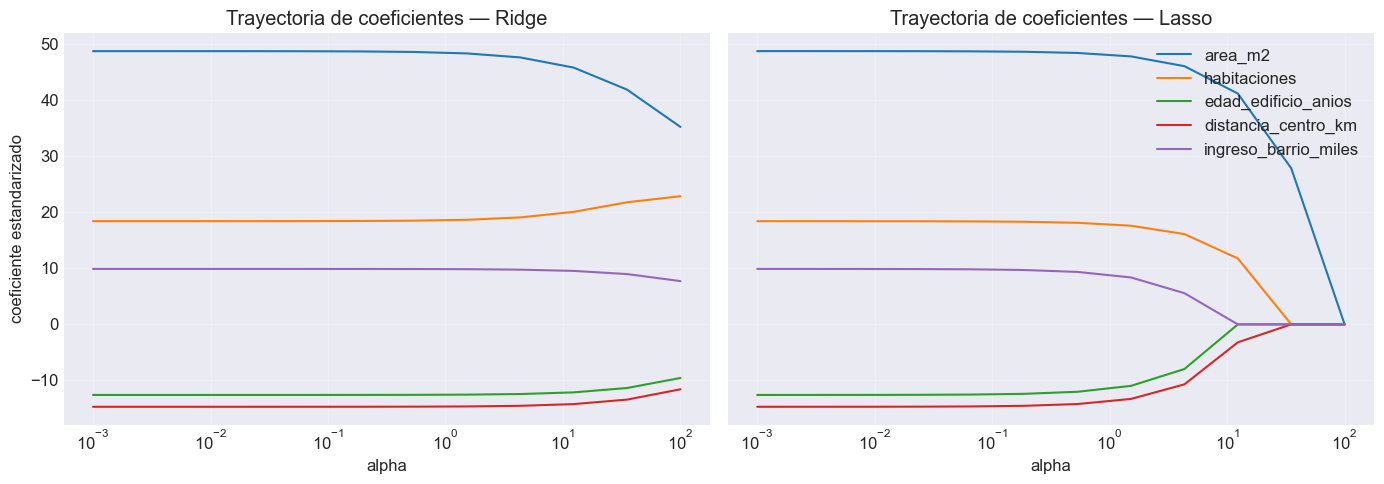

In [17]:
ridge_path_df = pd.concat(ridge_path_rows, ignore_index=True)
lasso_path_df = pd.concat(lasso_path_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for feature in reg_split["X_train"].columns:
    tmp = ridge_path_df[ridge_path_df["feature"] == feature]
    axes[0].plot(tmp["alpha"], tmp["coef"], label=feature)
axes[0].set_xscale("log")
axes[0].set_title("Trayectoria de coeficientes — Ridge")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("coeficiente estandarizado")

for feature in reg_split["X_train"].columns:
    tmp = lasso_path_df[lasso_path_df["feature"] == feature]
    axes[1].plot(tmp["alpha"], tmp["coef"], label=feature)
axes[1].set_xscale("log")
axes[1].set_title("Trayectoria de coeficientes — Lasso")
axes[1].set_xlabel("alpha")

axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

In [18]:
best_regression_models_df = pd.DataFrame(
    [
        {k: v for k, v in dummy_reg_row.items() if k != "fitted_model"},
        {k: v for k, v in linreg_raw_row.items() if k != "fitted_model"},
        {k: v for k, v in linreg_scaled_row.items() if k != "fitted_model"},
        {k: v for k, v in best_ridge.items() if k != "fitted_model"},
        {k: v for k, v in best_lasso.items() if k != "fitted_model"},
    ]
).sort_values("val_rmse")

print_section("MEJORES MODELOS DE REGRESIÓN")
display(best_regression_models_df)


                              MEJORES MODELOS DE REGRESIÓN                              


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
3,Ridge_alpha=4.3288,16.4751,13.1473,0.9434,17.0553,13.7318,0.9403
2,LinearRegression_scaled,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397
1,LinearRegression_raw,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397
4,Lasso_alpha=0.0010,16.5119,13.1804,0.9431,17.1337,13.8480,0.9397
0,DummyRegressor_mean,69.7305,57.8296,-0.0146,69.8098,61.5023,-0.0005


In [19]:
ridge_best_coef = extract_coefficients(best_ridge["fitted_model"], list(reg_split["X_train"].columns))
ridge_best_coef = ridge_best_coef.rename(columns={"coef": "ridge_best_coef"})

lasso_best_coef = extract_coefficients(best_lasso["fitted_model"], list(reg_split["X_train"].columns))
lasso_best_coef = lasso_best_coef.rename(columns={"coef": "lasso_best_coef"})

coef_shrinkage_df = (
    coef_scaled_df[["feature", "coef"]]
    .rename(columns={"coef": "linear_scaled_coef"})
    .merge(ridge_best_coef, on="feature", how="left")
    .merge(lasso_best_coef, on="feature", how="left")
)

print_section("SHRINKAGE DE COEFICIENTES")
display(coef_shrinkage_df)


                               SHRINKAGE DE COEFICIENTES                                


,feature,linear_scaled_coef,ridge_best_coef,lasso_best_coef
0,area_m2,48.7294,47.6097,48.7330
1,habitaciones,18.4061,19.0744,18.4021
2,distancia_centro_km,-14.6961,-14.5236,-14.6952
3,edad_edificio_anios,-12.5866,-12.4217,-12.5856
4,ingreso_barrio_miles,9.8866,9.7603,9.8856


### Lectura guiada del bloque

No mires solo la fila “ganadora”.

Preguntas importantes:

- ¿Qué pasa con los coeficientes cuando aumenta `alpha`?
- ¿Qué modelo tiende a encoger sin apagar?
- ¿Cuál puede llevar coeficientes exactamente a cero?
- ¿Por qué elegir `alpha` mirando test sería mala práctica?

---
## Rama de clasificación

Ahora mantenemos la familia lineal, pero cambiamos de tarea:

- ya no predecimos un valor continuo,
- ahora estimamos una probabilidad de clase positiva.

La clase positiva será:

- `maligno = 1`

Y el objetivo será separar claramente:

- score,
- probabilidad,
- decisión.

In [20]:
breast = load_breast_cancer(as_frame=True)

X_clf = breast.data.copy()
y_clf = pd.Series(1 - breast.target, name="maligno")

clf_split = split_train_val_test(
    X=X_clf,
    y=y_clf,
    stratify=y_clf,
    random_state=SEED,
)

print_section("DATASET DE CLASIFICACIÓN")
print(f"Shape de X_clf: {X_clf.shape}")
print("Clase positiva: maligno = 1")
display(y_clf.value_counts().rename("conteo"))
display(y_clf.value_counts(normalize=True).rename("proporción"))


                                DATASET DE CLASIFICACIÓN                                
Shape de X_clf: (569, 30)
Clase positiva: maligno = 1


maligno
0    357
1    212
Name: conteo, dtype: int64

maligno
0   0.6274
1   0.3726
Name: proporción, dtype: float64

### Baseline ingenua para clasificación

Igual que en regresión, conviene anclar una referencia simple:

- `DummyClassifier(strategy="prior")`

Eso nos ayuda a no confundir una frecuencia base con un modelo probabilístico serio.

In [21]:
dummy_clf = DummyClassifier(strategy="prior", random_state=SEED)
dummy_clf.fit(clf_split["X_train"], clf_split["y_train"])

dummy_val_proba = dummy_clf.predict_proba(clf_split["X_val"])[:, 1]
dummy_test_proba = dummy_clf.predict_proba(clf_split["X_test"])[:, 1]

dummy_clf_val_metrics = classification_metrics(
    y_true=clf_split["y_val"],
    proba=dummy_val_proba,
    threshold=0.50,
    cost_fn=5.0,
    cost_fp=1.0,
)

dummy_clf_test_metrics = classification_metrics(
    y_true=clf_split["y_test"],
    proba=dummy_test_proba,
    threshold=0.50,
    cost_fn=5.0,
    cost_fp=1.0,
)

print_section("BASELINE INGENUA DE CLASIFICACIÓN")
display(
    pd.DataFrame(
        [
            {
                "model": "DummyClassifier_prior",
                "val_log_loss": dummy_clf_val_metrics["log_loss"],
                "val_roc_auc": dummy_clf_val_metrics["roc_auc"],
                "test_log_loss": dummy_clf_test_metrics["log_loss"],
                "test_roc_auc": dummy_clf_test_metrics["roc_auc"],
            }
        ]
    )
)


                           BASELINE INGENUA DE CLASIFICACIÓN                            


,model,val_log_loss,val_roc_auc,test_log_loss,test_roc_auc
0,DummyClassifier_prior,0.6627,0.5000,0.6581,0.5000


### LogisticRegression con regularización

En este bloque:

- estandarizamos variables,
- exploramos distintos valores de `C`,
- elegimos el mejor usando **validation log loss**.

Recuerda:

- `C` grande = menos regularización,
- `C` pequeño = más regularización.

In [22]:
C_grid = np.logspace(-3, 3, 13)

logistic_rows = []

for C in C_grid:
    logistic_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    C=C,
                    penalty="l2",
                    solver="liblinear",
                    max_iter=5000,
                    random_state=SEED,
                ),
            ),
        ]
    )

    fitted = clone(logistic_model)
    fitted.fit(clf_split["X_train"], clf_split["y_train"])

    val_proba = fitted.predict_proba(clf_split["X_val"])[:, 1]
    test_proba = fitted.predict_proba(clf_split["X_test"])[:, 1]

    logistic_rows.append(
        {
            "C": C,
            "val_log_loss": log_loss(clf_split["y_val"], val_proba),
            "val_roc_auc": roc_auc_score(clf_split["y_val"], val_proba),
            "test_log_loss": log_loss(clf_split["y_test"], test_proba),
            "test_roc_auc": roc_auc_score(clf_split["y_test"], test_proba),
            "fitted_model": fitted,
        }
    )

logistic_results_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k != "fitted_model"} for row in logistic_rows]
).sort_values("val_log_loss")

print_section("BÚSQUEDA DE C EN LOGÍSTICA")
display(logistic_results_df)

best_logistic_row = min(logistic_rows, key=lambda row: row["val_log_loss"])
best_logistic_model = best_logistic_row["fitted_model"]
best_C = best_logistic_row["C"]

print(f"Mejor C por validation log loss: {best_C:.4f}")


                               BÚSQUEDA DE C EN LOGÍSTICA                               


,C,val_log_loss,val_roc_auc,test_log_loss,test_roc_auc
6,1.0000,0.0722,0.9957,0.0788,0.9954
7,3.1623,0.0730,0.9957,0.1010,0.9914
8,10.0000,0.0810,0.9957,0.1520,0.9881
5,0.3162,0.0825,0.9964,0.0814,0.9970
9,31.6228,0.1001,0.9957,0.2404,0.9835
4,0.1000,0.1051,0.9944,0.1001,0.9977
10,100.0000,0.1332,0.9957,0.3809,0.9795
3,0.0316,0.1433,0.9941,0.1376,0.9977
11,316.2278,0.1762,0.9961,0.5724,0.9765
2,0.0100,0.2080,0.9921,0.2016,0.9980


Mejor C por validation log loss: 1.0000


In [23]:
val_proba_best = best_logistic_model.predict_proba(clf_split["X_val"])[:, 1]
test_proba_best = best_logistic_model.predict_proba(clf_split["X_test"])[:, 1]

clf_baseline_vs_logistic = pd.DataFrame(
    [
        {
            "model": "DummyClassifier_prior",
            "val_log_loss": dummy_clf_val_metrics["log_loss"],
            "val_roc_auc": dummy_clf_val_metrics["roc_auc"],
            "test_log_loss": dummy_clf_test_metrics["log_loss"],
            "test_roc_auc": dummy_clf_test_metrics["roc_auc"],
        },
        {
            "model": f"LogisticRegression_C={best_C:.4f}",
            "val_log_loss": log_loss(clf_split["y_val"], val_proba_best),
            "val_roc_auc": roc_auc_score(clf_split["y_val"], val_proba_best),
            "test_log_loss": log_loss(clf_split["y_test"], test_proba_best),
            "test_roc_auc": roc_auc_score(clf_split["y_test"], test_proba_best),
        },
    ]
)

print_section("BASELINE VS LOGISTIC REGRESSION")
display(clf_baseline_vs_logistic)


                            BASELINE VS LOGISTIC REGRESSION                             


,model,val_log_loss,val_roc_auc,test_log_loss,test_roc_auc
0,DummyClassifier_prior,0.6627,0.5000,0.6581,0.5000
1,LogisticRegression_C=1.0000,0.0722,0.9957,0.0788,0.9954


---
## Probabilidades, threshold tuning y métricas

Aquí está una de las ideas más importantes del capítulo:

- el modelo produce una **probabilidad estimada**,
- la política define una **decisión final**.

Por eso, `0.5` no debe tratarse como default universal.

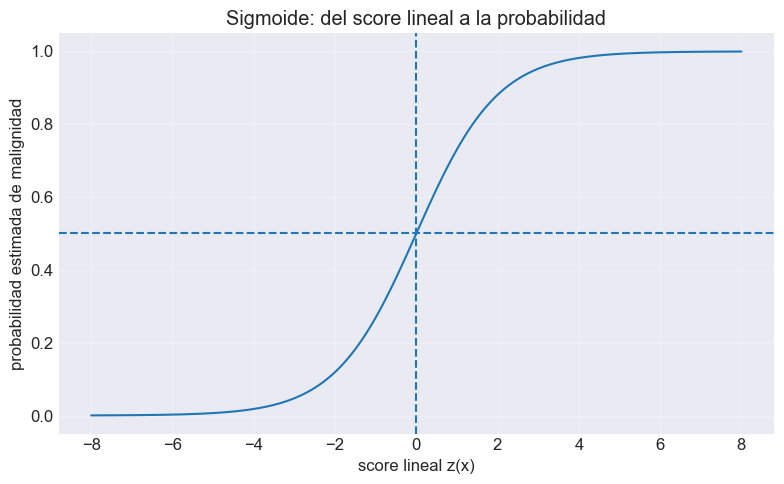

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
z = np.linspace(-8, 8, 500)
sigmoid = 1 / (1 + np.exp(-z))
ax.plot(z, sigmoid)
ax.axhline(0.5, linestyle="--")
ax.axvline(0, linestyle="--")
ax.set_title("Sigmoide: del score lineal a la probabilidad")
ax.set_xlabel("score lineal z(x)")
ax.set_ylabel("probabilidad estimada de malignidad")
plt.tight_layout()
plt.show()

In [25]:
toy_probs = pd.DataFrame(
    {
        "caso": ["A", "B", "C", "D"],
        "prob_maligno": [0.22, 0.48, 0.61, 0.83],
    }
)

toy_probs["decision_tau_0_50"] = (toy_probs["prob_maligno"] >= 0.50).astype(int)
toy_probs["decision_tau_0_30"] = (toy_probs["prob_maligno"] >= 0.30).astype(int)
toy_probs["decision_tau_0_70"] = (toy_probs["prob_maligno"] >= 0.70).astype(int)

print_section("PROBABILIDAD VS DECISIÓN")
display(toy_probs)


                                PROBABILIDAD VS DECISIÓN                                


,caso,prob_maligno,decision_tau_0_50,decision_tau_0_30,decision_tau_0_70
0,A,0.2200,0,0,0
1,B,0.4800,0,1,0
2,C,0.6100,1,1,0
3,D,0.8300,1,1,1


### Nota conceptual

Mira la tabla anterior con cuidado:

- la probabilidad estimada es la misma,
- la acción cambia cuando cambia el threshold.

Eso significa:

> cambiar el threshold cambia la decisión, no la probabilidad estimada.

### Threshold tuning con costo asimétrico

Usaremos una política de screening:

- costo FN = 5
- costo FP = 1

Esto favorece evitar falsos negativos, incluso si suben algo los falsos positivos.

In [26]:
cost_fn = 5.0
cost_fp = 1.0
thresholds = np.linspace(0.05, 0.95, 91)

threshold_df = threshold_sweep(
    y_true=clf_split["y_val"],
    proba=val_proba_best,
    thresholds=thresholds,
    cost_fn=cost_fn,
    cost_fp=cost_fp,
)

print_section("BARRIDO DE THRESHOLDS EN VALIDACIÓN")
display(threshold_df.head())

best_threshold_row = threshold_df.sort_values(
    ["policy_cost", "fn", "threshold"],
    ascending=[True, True, True],
).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print(f"Threshold elegido en validación: {best_threshold:.2f}")
print(f"Costo de política mínimo en validación: {best_threshold_row['policy_cost']:.2f}")


                          BARRIDO DE THRESHOLDS EN VALIDACIÓN                           


,threshold,accuracy,precision,recall,specificity,f1,roc_auc,log_loss,tn,fp,fn,tp,policy_cost
0,0.0500,0.8509,0.7167,1.0000,0.7606,0.8350,0.9957,0.0722,54,17,0,43,17.0000
1,0.0600,0.8596,0.7288,1.0000,0.7746,0.8431,0.9957,0.0722,55,16,0,43,16.0000
2,0.0700,0.8684,0.7414,1.0000,0.7887,0.8515,0.9957,0.0722,56,15,0,43,15.0000
3,0.0800,0.8684,0.7414,1.0000,0.7887,0.8515,0.9957,0.0722,56,15,0,43,15.0000
4,0.0900,0.8772,0.7544,1.0000,0.8028,0.8600,0.9957,0.0722,57,14,0,43,14.0000


Threshold elegido en validación: 0.68
Costo de política mínimo en validación: 5.00


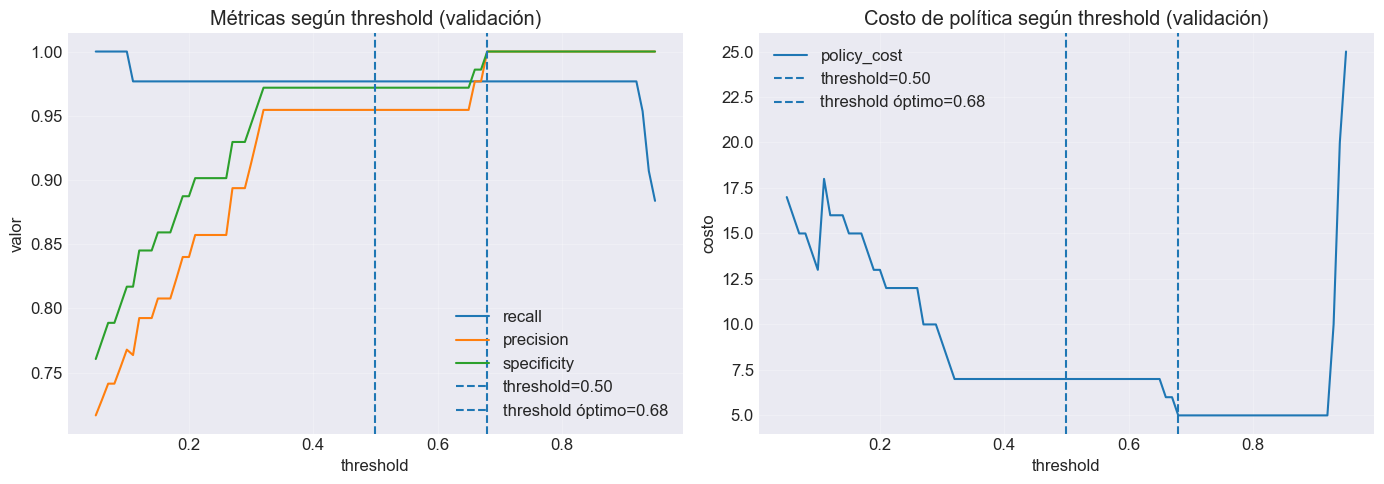

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
axes[0].plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
axes[0].plot(threshold_df["threshold"], threshold_df["specificity"], label="specificity")
axes[0].axvline(0.50, linestyle="--", label="threshold=0.50")
axes[0].axvline(best_threshold, linestyle="--", label=f"threshold óptimo={best_threshold:.2f}")
axes[0].set_title("Métricas según threshold (validación)")
axes[0].set_xlabel("threshold")
axes[0].set_ylabel("valor")
axes[0].legend()

axes[1].plot(threshold_df["threshold"], threshold_df["policy_cost"], label="policy_cost")
axes[1].axvline(0.50, linestyle="--", label="threshold=0.50")
axes[1].axvline(best_threshold, linestyle="--", label=f"threshold óptimo={best_threshold:.2f}")
axes[1].set_title("Costo de política según threshold (validación)")
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("costo")
axes[1].legend()

plt.tight_layout()
plt.show()

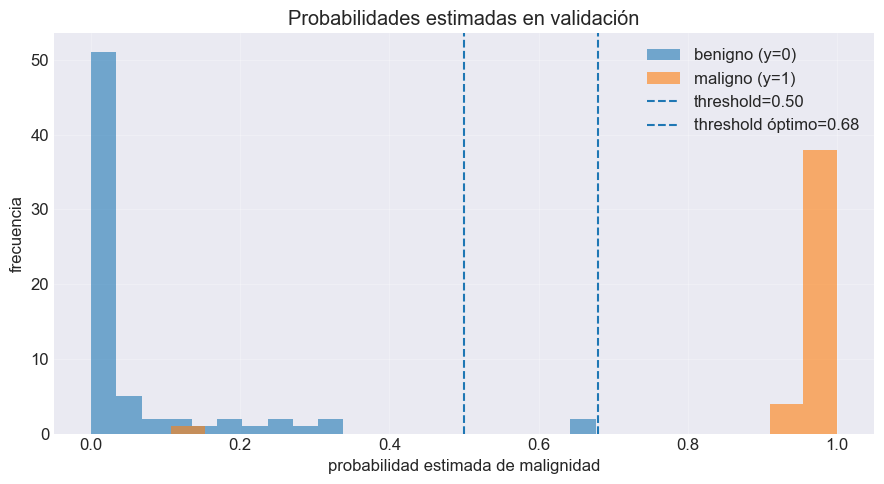

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    val_proba_best[clf_split["y_val"] == 0],
    bins=20,
    alpha=0.6,
    label="benigno (y=0)",
)
ax.hist(
    val_proba_best[clf_split["y_val"] == 1],
    bins=20,
    alpha=0.6,
    label="maligno (y=1)",
)

ax.axvline(0.50, linestyle="--", label="threshold=0.50")
ax.axvline(best_threshold, linestyle="--", label=f"threshold óptimo={best_threshold:.2f}")
ax.set_title("Probabilidades estimadas en validación")
ax.set_xlabel("probabilidad estimada de malignidad")
ax.set_ylabel("frecuencia")
ax.legend()

plt.tight_layout()
plt.show()

### Curvas de desempeño probabilístico

Estas curvas ayudan a mirar el comportamiento global de las probabilidades.

Pero recuerda:

- una buena curva no reemplaza la necesidad de elegir una política concreta.

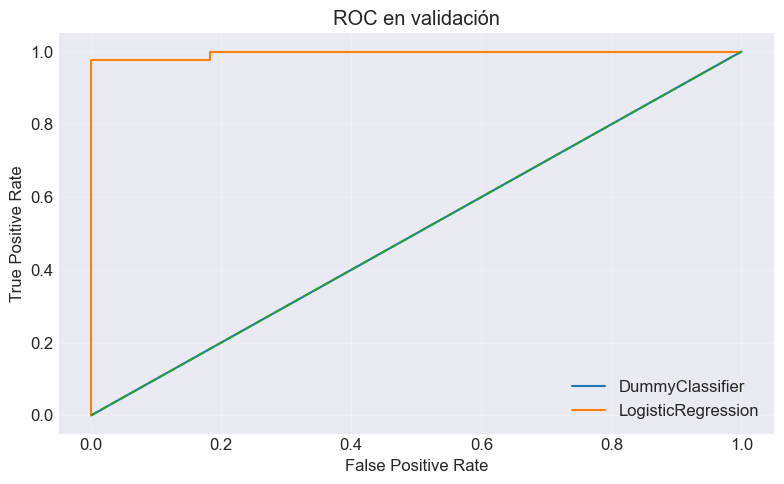

In [29]:
fpr_dummy, tpr_dummy, _ = roc_curve(clf_split["y_val"], dummy_val_proba)
fpr_best, tpr_best, _ = roc_curve(clf_split["y_val"], val_proba_best)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fpr_dummy, tpr_dummy, label="DummyClassifier")
ax.plot(fpr_best, tpr_best, label="LogisticRegression")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC en validación")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

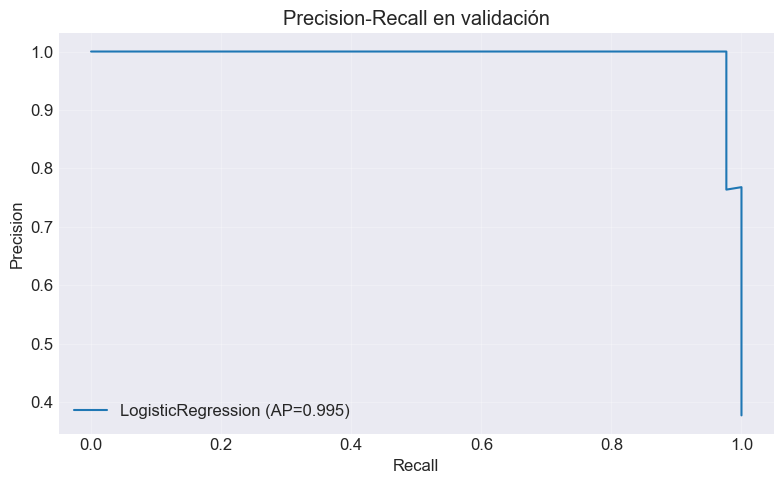

In [30]:
precision_vals, recall_vals, _ = precision_recall_curve(clf_split["y_val"], val_proba_best)
ap = average_precision_score(clf_split["y_val"], val_proba_best)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_vals, precision_vals, label=f"LogisticRegression (AP={ap:.3f})")
ax.set_title("Precision-Recall en validación")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
test_default_metrics = classification_metrics(
    y_true=clf_split["y_test"],
    proba=test_proba_best,
    threshold=0.50,
    cost_fn=cost_fn,
    cost_fp=cost_fp,
)

test_tuned_metrics = classification_metrics(
    y_true=clf_split["y_test"],
    proba=test_proba_best,
    threshold=best_threshold,
    cost_fn=cost_fn,
    cost_fp=cost_fp,
)

classification_summary_df = pd.DataFrame(
    [
        {"policy": "default_0.50", **test_default_metrics},
        {"policy": "tuned_validation_threshold", **test_tuned_metrics},
    ]
)

print_section("COMPARACIÓN DE POLÍTICAS EN TEST")
display(classification_summary_df)


                            COMPARACIÓN DE POLÍTICAS EN TEST                            


,policy,threshold,accuracy,precision,recall,specificity,f1,roc_auc,log_loss,tn,fp,fn,tp,policy_cost
0,default_0.50,0.5000,0.9737,0.9756,0.9524,0.9861,0.9639,0.9954,0.0788,71,1,2,40,11.0000
1,tuned_validation_threshold,0.6800,0.9737,1.0000,0.9286,1.0000,0.9630,0.9954,0.0788,72,0,3,39,15.0000


### Lectura metodológica del bloque

Antes de celebrar un número, responde:

- ¿Qué cambió entre la política default y la política ajustada?
- ¿Qué se mantuvo constante?
- ¿Por qué sería incorrecto elegir este threshold mirando primero test?

---
## Coeficientes logísticos e interpretación mínima

En el modelo logístico escalado, los coeficientes pueden leerse como cambios en **log-odds** por un incremento de una desviación estándar en la feature.

Eso ayuda a ordenar el razonamiento, pero sigue teniendo límites:

- no es probabilidad directa,
- no es causalidad,
- no es una medida universal de importancia.

In [32]:
coef_logistic_df = extract_coefficients(best_logistic_model, list(clf_split["X_train"].columns))
coef_logistic_df["abs_coef"] = coef_logistic_df["coef"].abs()
coef_logistic_df["odds_ratio_aprox_por_+1sd"] = np.exp(coef_logistic_df["coef"])
coef_logistic_df = coef_logistic_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

print_section("COEFICIENTES DE REGRESIÓN LOGÍSTICA")
display(coef_logistic_df.head(12))


                          COEFICIENTES DE REGRESIÓN LOGÍSTICA                           


,feature,coef,abs_coef,odds_ratio_aprox_por_+1sd
0,worst texture,1.3512,1.3512,3.8621
1,mean concave points,1.1099,1.1099,3.0340
2,radius error,1.0294,1.0294,2.7993
3,worst symmetry,0.9502,0.9502,2.5862
4,worst area,0.8103,0.8103,2.2487
5,worst radius,0.8091,0.8091,2.2460
6,area error,0.7994,0.7994,2.2243
7,worst concavity,0.7765,0.7765,2.1739
8,mean concavity,0.7740,0.7740,2.1684
9,compactness error,-0.7634,0.7634,0.4661


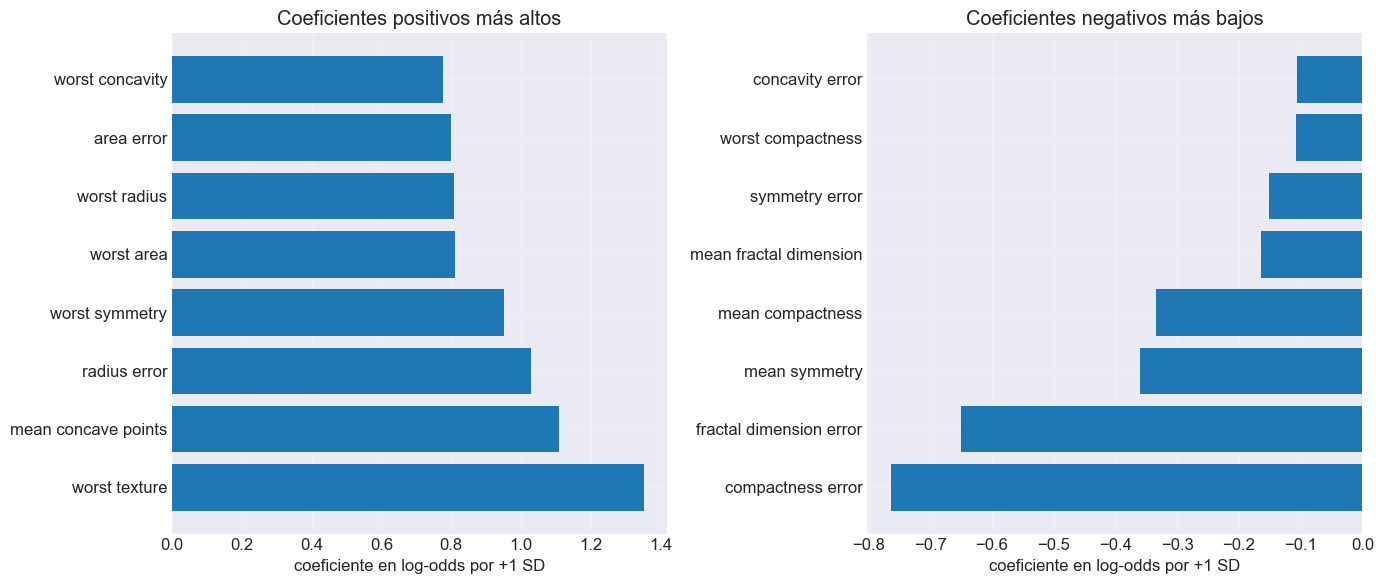

In [33]:
top_pos = coef_logistic_df.sort_values("coef", ascending=False).head(8)
top_neg = coef_logistic_df.sort_values("coef", ascending=True).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_pos["feature"], top_pos["coef"])
axes[0].set_title("Coeficientes positivos más altos")
axes[0].set_xlabel("coeficiente en log-odds por +1 SD")

axes[1].barh(top_neg["feature"], top_neg["coef"])
axes[1].set_title("Coeficientes negativos más bajos")
axes[1].set_xlabel("coeficiente en log-odds por +1 SD")

plt.tight_layout()
plt.show()

---
## Resumen final de resultados

En este punto queremos una vista compacta por rama:

- regresión,
- clasificación.

La meta no es “ganar” un benchmark, sino instalar una baseline family seria, interpretable y defendible.

In [34]:
regression_summary = best_regression_models_df[
    ["model", "val_rmse", "val_mae", "val_r2", "test_rmse", "test_mae", "test_r2"]
].copy()

classification_summary = classification_summary_df[
    [
        "policy",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1",
        "roc_auc",
        "log_loss",
        "fp",
        "fn",
        "policy_cost",
    ]
].copy()

print_section("RESUMEN DE REGRESIÓN")
display(regression_summary)

print_section("RESUMEN DE CLASIFICACIÓN")
display(classification_summary)


                                  RESUMEN DE REGRESIÓN                                  


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
3,Ridge_alpha=4.3288,16.4751,13.1473,0.9434,17.0553,13.7318,0.9403
2,LinearRegression_scaled,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397
1,LinearRegression_raw,16.5115,13.1801,0.9431,17.1332,13.8474,0.9397
4,Lasso_alpha=0.0010,16.5119,13.1804,0.9431,17.1337,13.8480,0.9397
0,DummyRegressor_mean,69.7305,57.8296,-0.0146,69.8098,61.5023,-0.0005



                                RESUMEN DE CLASIFICACIÓN                                


,policy,threshold,accuracy,precision,recall,specificity,f1,roc_auc,log_loss,fp,fn,policy_cost
0,default_0.50,0.5000,0.9737,0.9756,0.9524,0.9861,0.9639,0.9954,0.0788,1,2,11.0000
1,tuned_validation_threshold,0.6800,0.9737,1.0000,0.9286,1.0000,0.9630,0.9954,0.0788,0,3,15.0000


---
## Glosario mínimo

- **Score lineal**: combinación ponderada de features e intercepto.
- **MSE**: promedio de errores cuadrados en regresión.
- **Log loss**: pérdida para clasificación probabilística binaria.
- **Ridge**: regularización L2 que contrae coeficientes.
- **Lasso**: regularización L1 que puede inducir sparsity.
- **Sigmoide**: función que transforma un score real en probabilidad entre 0 y 1.
- **Threshold**: regla que convierte probabilidad estimada en decisión.
- **Residuo**: diferencia entre valor real y valor predicho en regresión.

---
## Práctica activa y preguntas de reflexión

### Práctica 1 — Lectura de coeficientes

Escribe una interpretación correcta y una incorrecta para dos coeficientes del modelo lineal.

**Pista**:
- la correcta debe incluir la frase “manteniendo lo demás constante en el sentido del modelo”,
- la incorrecta debe mostrar el salto indebido hacia causalidad.

### Práctica 2 — Scaling

Mira `coef_compare_df` y responde:

1. ¿Qué variable parecía dominar sin scaling?
2. ¿Cambió la lectura al pasar a coeficientes estandarizados?
3. ¿Por qué esta advertencia se vuelve más importante con regularización?

### Práctica 3 — Regularización

Observa las trayectorias de Ridge y Lasso:

1. ¿Cuál encoge de forma más distribuida?
2. ¿Cuál puede inducir sparsity?
3. ¿Qué se gana y qué se puede perder al aumentar `alpha`?

### Práctica 4 — Threshold como política

Cambia la política de costos a:

- costo FN = 10
- costo FP = 1

y recalcula el threshold óptimo.

### Práctica 5 — Juicio técnico

Responde en 3 a 5 líneas:

1. ¿Qué parte de este notebook corresponde al modelo?
2. ¿Qué parte corresponde a la política?
3. ¿Qué parte corresponde a la evaluación?
4. ¿Qué error te parece más peligroso en esta sesión: mala interpretación de coeficientes o mala selección de threshold?

In [35]:
print_section("PLANTILLA DE RESPUESTA DEL ESTUDIANTE")

student_reflection = pd.DataFrame(
    {
        "pregunta": [
            "Interpretación correcta de un coeficiente lineal",
            "Interpretación incorrecta y por qué lo es",
            "Qué cambió con scaling",
            "Qué aprendí de Ridge vs Lasso",
            "Qué justifica mover el threshold",
            "Qué nunca debería decidirse con test",
        ],
        "respuesta": ["", "", "", "", "", ""],
    }
)

display(student_reflection)


                         PLANTILLA DE RESPUESTA DEL ESTUDIANTE                          


,pregunta,respuesta
0,Interpretación correcta de un coeficiente lineal,
1,Interpretación incorrecta y por qué lo es,
2,Qué cambió con scaling,
3,Qué aprendí de Ridge vs Lasso,
4,Qué justifica mover el threshold,
5,Qué nunca debería decidirse con test,


---
## Cierre del capítulo

### Resumen estructural

En esta sesión quedaron instaladas cinco piezas del vocabulario base del curso:

- familia lineal,
- score,
- pérdida,
- regularización,
- threshold.

### Reglas de interpretación

- un coeficiente predictivo no prueba causalidad;
- la comparabilidad de coeficientes depende de la escala;
- una probabilidad estimada no es todavía una decisión;
- el threshold es política, no propiedad fija del modelo.

### Puente a la siguiente sesión

Ahora que ya existe una baseline family del curso, la siguiente pregunta natural es:

> ¿cómo validar, comparar y seleccionar modelos sin engañarnos?

Ese es el puente directo hacia la sesión de validación, selección de modelos y comparación rigurosa.

---

## Preguntas de autoevaluación

1. ¿Qué diferencia conceptual existe entre score, probabilidad y decisión?
2. ¿Por qué `0.5` no debe tratarse como threshold universal?
3. ¿Cuándo mirarías con más cautela la magnitud de un coeficiente?
4. ¿Qué problema intenta resolver la regularización?
5. ¿Qué parte del flujo documentarías con más cuidado para otro miembro del equipo?

## Material adicional y referencias

### Referencias bibliográficas

In [36]:
references = """
📚 REFERENCIAS Y LECTURAS RECOMENDADAS:

Libros fundamentales:
• Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow
• Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning
• James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning

Modelos lineales y regularización:
• Hoerl, A. E., & Kennard, R. W. (1970). Ridge Regression
• Tibshirani, R. (1996). Regression Shrinkage and Selection via the Lasso

Clasificación probabilística y decisión:
• Murphy, K. P. (2012). Machine Learning: A Probabilistic Perspective
• Provost, F., & Fawcett, T. (2013). Data Science for Business

Recursos online:
• Documentación scikit-learn: https://scikit-learn.org/stable/
• Linear models in scikit-learn: https://scikit-learn.org/stable/modules/linear_model.html
• Metrics and model evaluation: https://scikit-learn.org/stable/modules/model_evaluation.html
"""

print(references)


📚 REFERENCIAS Y LECTURAS RECOMENDADAS:

Libros fundamentales:
• Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow
• Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning
• James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning

Modelos lineales y regularización:
• Hoerl, A. E., & Kennard, R. W. (1970). Ridge Regression
• Tibshirani, R. (1996). Regression Shrinkage and Selection via the Lasso

Clasificación probabilística y decisión:
• Murphy, K. P. (2012). Machine Learning: A Probabilistic Perspective
• Provost, F., & Fawcett, T. (2013). Data Science for Business

Recursos online:
• Documentación scikit-learn: https://scikit-learn.org/stable/
• Linear models in scikit-learn: https://scikit-learn.org/stable/modules/linear_model.html
• Metrics and model evaluation: https://scikit-learn.org/stable/modules/model_evaluation.html



---

**Fin del Notebook**

*Última actualización: 2026*  
*Autor: Marco Teran*